# 03 — Embeddings

Comparaison de cinq représentations vectorielles :
| Méthode | Type | Contexte |
|---|---|---|
| **TF-IDF** | sparse, statistique | non |
| **Word2Vec** | dense, entraîné | local |
| **FastText** | dense, sous-mots | local |
| **GloVe** | dense, pré-entraîné | global |
| **BERT** | dense, contextuel | global |

Chaque section produit une matrice d'embeddings, une visualisation t-SNE, et sauvegarde le modèle.

## 0 — Imports & données

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from vectorizer import (
    # TF-IDF
    get_tfidf_vectors, save_vectorizer, load_vectorizer,
    # Word2Vec
    get_word2vec_embeddings, save_word2vec, load_word2vec,
    # FastText
    get_fasttext_embeddings, save_fasttext, load_fasttext,
    # GloVe
    load_glove_index, get_glove_embeddings,
    # BERT
    get_bert_embeddings,
    # Générique numpy
    save_embeddings, load_embeddings,
)

In [2]:
#Decommenter si cest pas installer
#pip install gensim sentence-transformers

In [3]:
df = pd.read_csv('../data/processed/dataset_clean.csv')
texts  = df['clean_text'].tolist()
labels = df['class'].tolist()
print(f'{len(texts)} exemples chargés')
df.head(3)

24782 exemples chargés


,count,hate_speech,offensive_language,neither,class,tweet,clean_text
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,woman shouldnt complain clean house. amp man t...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,boy dats cold...tyga dwn bad cuffin dat hoe 1s...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,dawg fuck bitch start confuse shit


## Utilitaire — visualisation t-SNE

In [4]:
def plot_tsne(X, labels, title: str, n_samples: int = 500, dense: bool = True):
    """Visualise un échantillon d'embeddings en 2D via t-SNE."""
    idx = np.random.choice(len(labels), min(n_samples, len(labels)), replace=False)
    X_s = X[idx].toarray() if not dense else X[idx]
    y_s = [labels[i] for i in idx]

    X_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_s)

    plt.figure(figsize=(8, 6))
    for label in sorted(set(y_s)):
        mask = np.array([l == label for l in y_s])
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=label, alpha=0.6, s=20)
    plt.title(f't-SNE — {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()

---
## 1 — TF-IDF

Représentation **sparse** basée sur la fréquence des termes pondérée par leur rareté dans le corpus.  
Bigrams inclus (`ngram_range=(1,2)`), log-normalisation active (`sublinear_tf=True`).

In [5]:
X_tfidf = get_tfidf_vectors(texts, fit=True, max_features=10_000)
save_vectorizer('tfidf_vectorizer.pkl')
print(f'TF-IDF shape : {X_tfidf.shape}')

[TF-IDF] Vectorizer sauvegardé : G:\models\saved\tfidf_vectorizer.pkl
TF-IDF shape : (24782, 10000)


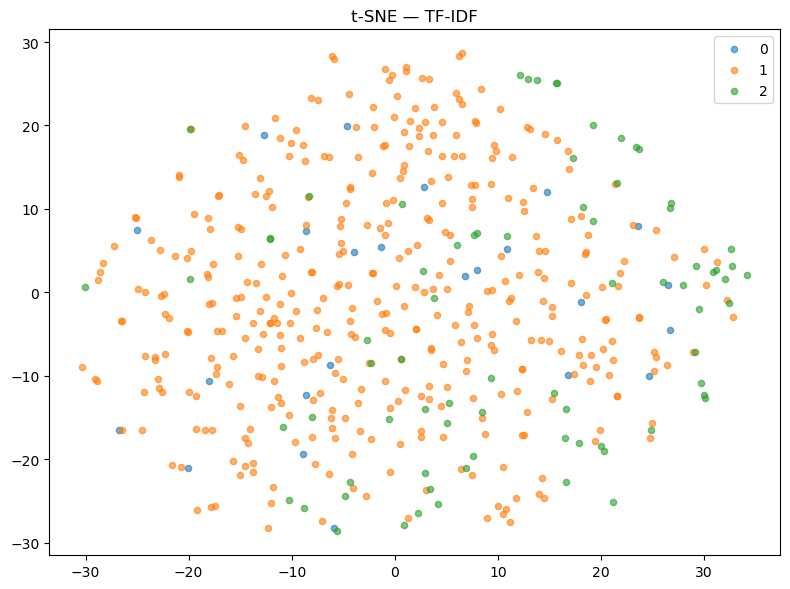

In [6]:
plot_tsne(X_tfidf, labels, 'TF-IDF', dense=False)

---
## 2 — Word2Vec

Modèle **Skip-Gram / CBOW** (gensim) entraîné sur le corpus.  
Chaque texte est représenté par la **moyenne** des vecteurs de ses mots connus.  
⚠️ Les mots hors-vocabulaire sont ignorés (contrairement à FastText).

In [7]:
X_w2v = get_word2vec_embeddings(
    texts,
    vector_size=100,
    window=5,
    min_count=2,
    epochs=10,
    fit=True,
)
save_word2vec('word2vec.model')
print(f'Word2Vec shape : {X_w2v.shape}')

[Word2Vec] Entraînement en cours...
[Word2Vec] Vocabulaire : 8897 mots
[Word2Vec] Modèle sauvegardé : G:\models\saved\word2vec.model
Word2Vec shape : (24782, 100)


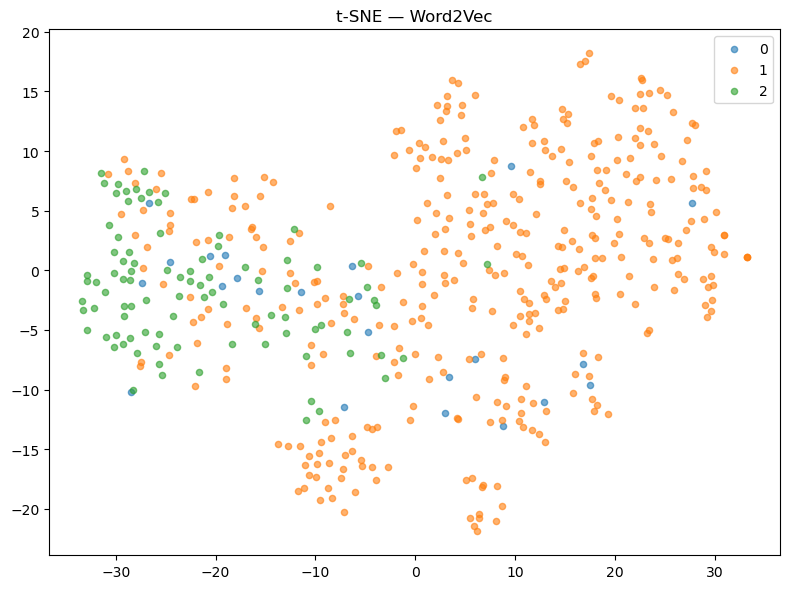

In [8]:
plot_tsne(X_w2v, labels, 'Word2Vec')

---
## 3 — FastText

Extension de Word2Vec utilisant des **n-grammes de caractères**.  
Avantages : robustesse aux fautes d'orthographe, slang, mots rares — fréquents en hate speech.

In [9]:
X_ft = get_fasttext_embeddings(
    texts,
    vector_size=100,
    window=5,
    min_count=2,
    epochs=10,
    fit=True,
)
save_fasttext('fasttext.model')
print(f'FastText shape : {X_ft.shape}')

[FastText] Entraînement en cours...
[FastText] Vocabulaire : 8897 mots
[FastText] Modèle sauvegardé : G:\models\saved\fasttext.model
FastText shape : (24782, 100)


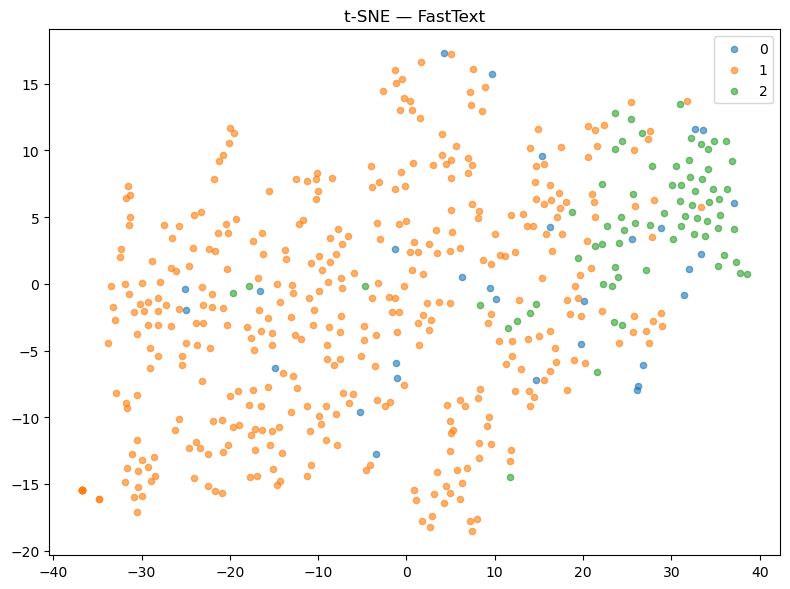

In [10]:
plot_tsne(X_ft, labels, 'FastText')

---
## 4 — GloVe

Vecteurs pré-entraînés sur Common Crawl / Wikipedia (Stanford).  
Téléchargement : https://nlp.stanford.edu/projects/glove/  
Fichier recommandé : `glove.6B.100d.txt` (dimension 100, ~800 MB dézippé).

Modifiez `GLOVE_PATH` ci-dessous selon votre arborescence.

In [11]:
# GLOVE_PATH = '../models/glove/glove.6B.100d.txt'  # ← à adapter

# X_glove = get_glove_embeddings(texts, glove_path=GLOVE_PATH, vector_size=100)
# save_embeddings(X_glove, 'glove_embeddings')
# print(f'GloVe shape : {X_glove.shape}')

#save_embeddings(X_glove, 'glove_embeddings')

In [12]:
#plot_tsne(X_glove, labels, 'GloVe')

---
## 5 — BERT (Sentence-Transformers)

Encodeur **contextuel** : la représentation d'un mot dépend du contexte complet de la phrase.  
Modèles suggérés :
- `all-MiniLM-L6-v2` — rapide, bon compromis (384 dim)
- `all-mpnet-base-v2` — plus précis (768 dim)
- `GroNLP/hateBERT` — fine-tuné sur du hate speech

⚠️ Sur CPU, prévoir plusieurs minutes pour un grand corpus.

In [13]:
X_bert = get_bert_embeddings(
    texts,
    model_name='all-MiniLM-L6-v2',
    batch_size=64,
)
save_embeddings(X_bert, 'bert_embeddings')
print(f'BERT shape : {X_bert.shape}')

[BERT] Chargement du modèle : all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/388 [00:00<?, ?it/s]

[Embeddings] Sauvegardé : G:\models\saved\bert_embeddings.npy
BERT shape : (24782, 384)


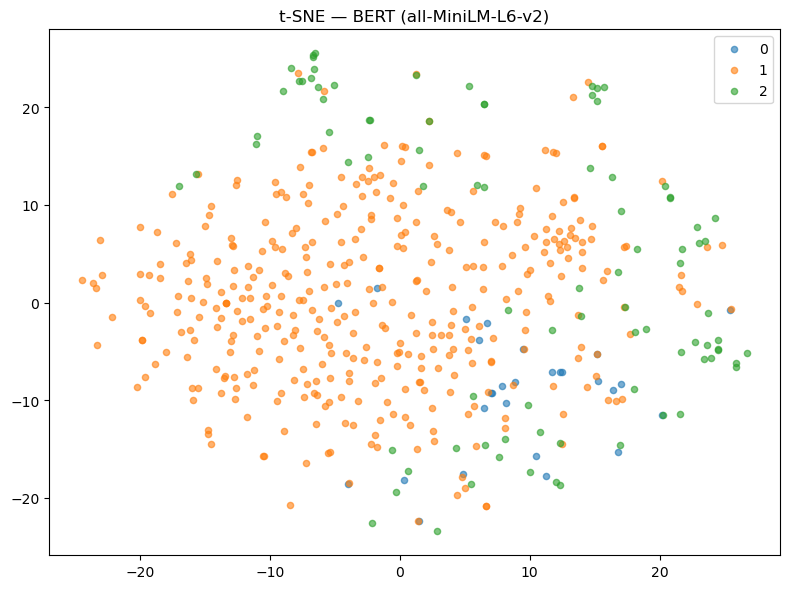

In [14]:
plot_tsne(X_bert, labels, 'BERT (all-MiniLM-L6-v2)')

---
## 6 — Comparaison rapide des méthodes

Résumé qualitatif des cinq approches sur le même échantillon.

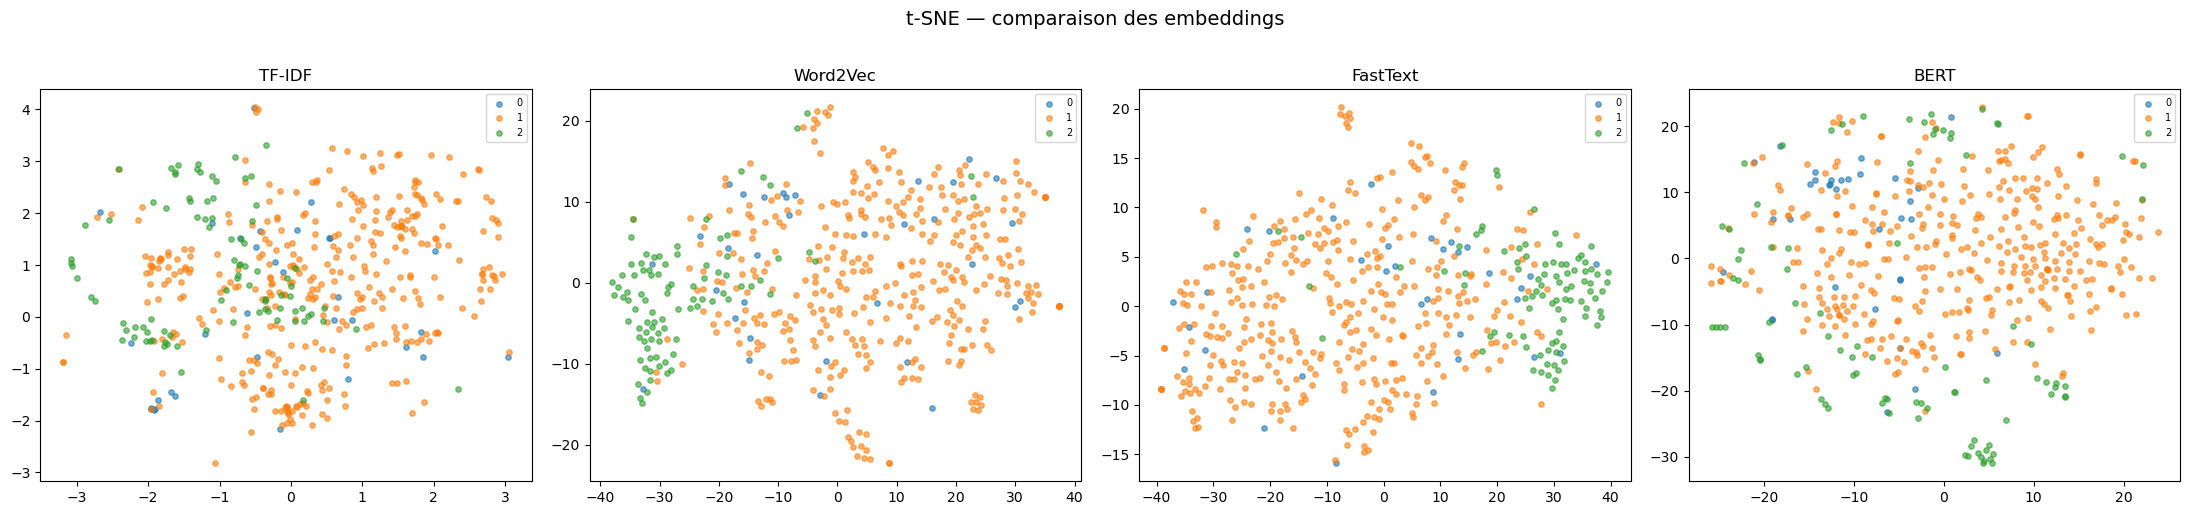

In [15]:
METHODS = [
    ('TF-IDF',    X_tfidf,  False),
    ('Word2Vec',  X_w2v,    True),
    ('FastText',  X_ft,     True),
    #('GloVe',     X_glove,  True),
    ('BERT',      X_bert,   True),
]

np.random.seed(42)
n_samples = 500
idx = np.random.choice(len(labels), min(n_samples, len(labels)), replace=False)
y_s = [labels[i] for i in idx]
unique_labels = sorted(set(y_s))

fig, axes = plt.subplots(1, len(METHODS), figsize=(22, 5))

for ax, (name, X, dense) in zip(axes, METHODS):
    X_s = X[idx] if dense else X[idx].toarray()
    X_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_s)
    for label in unique_labels:
        mask = np.array([l == label for l in y_s])
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=label, alpha=0.6, s=15)
    ax.set_title(name)
    ax.legend(fontsize=7)

plt.suptitle('t-SNE — comparaison des embeddings', fontsize=14, y=1.02)
plt.tight_layout()
import os
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7 — Récapitulatif

| Méthode | Dim | Type | OOV | Contexte | Vitesse |
|---|---|---|---|---|---|
| TF-IDF | 10 000 | sparse | ✗ | ✗ | ⚡⚡⚡ |
| Word2Vec | 100 | dense | ✗ | local | ⚡⚡ |
| FastText | 100 | dense | ✓ | local | ⚡⚡ |
| GloVe | 100 | dense | ✗ | global | ⚡⚡ |
| BERT | 384 | dense | ✓ | global | ⚡ |

Les embeddings sont sauvegardés dans `models/saved/` et réutilisables dans les notebooks suivants (04 — Classification).